# 📈 Sales Forecasting
### Predicting monthly revenue using historical sales data
**Dataset:** Superstore Sales | **Model:** Holt-Winters Exponential Smoothing | **MAE:** $12,931.85

## Stage 1 — Load & Explore the Data
We start by loading the dataset and taking a first look at its structure —
checking column names, data types, and overall shape before touching anything.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# First look
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.columns.tolist())

(9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       4

## Stage 2 — Clean & Prepare the Data
Raw sales data comes with dates stored as plain text. We convert them to proper
datetime format, extract time features (year, month), and aggregate individual
orders into monthly totals — the format a forecasting model needs.

In [3]:
# Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract useful time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Aggregate sales by month
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
monthly_sales['Sales'] = monthly_sales['Sales'].round(2)

print(monthly_sales)

   YearMonth      Sales
0    2014-01   14236.90
1    2014-02    4519.89
2    2014-03   55691.01
3    2014-04   28295.34
4    2014-05   23648.29
5    2014-06   34595.13
6    2014-07   33946.39
7    2014-08   27909.47
8    2014-09   81777.35
9    2014-10   31453.39
10   2014-11   78628.72
11   2014-12   69545.62
12   2015-01   18174.08
13   2015-02   11951.41
14   2015-03   38726.25
15   2015-04   34195.21
16   2015-05   30131.69
17   2015-06   24797.29
18   2015-07   28765.32
19   2015-08   36898.33
20   2015-09   64595.92
21   2015-10   31404.92
22   2015-11   75972.56
23   2015-12   74919.52
24   2016-01   18542.49
25   2016-02   22978.82
26   2016-03   51715.88
27   2016-04   38750.04
28   2016-05   56987.73
29   2016-06   40344.53
30   2016-07   39261.96
31   2016-08   31115.37
32   2016-09   73410.02
33   2016-10   59687.74
34   2016-11   79411.97
35   2016-12   96999.04
36   2017-01   43971.37
37   2017-02   20301.13
38   2017-03   58872.35
39   2017-04   36521.54
40   2017-05   4

## Stage 3 — Visualize the Trend
Before building any model, we plot the data. We're looking for three things:
trend (is sales growing?), seasonality (any recurring spikes?), and anomalies
(any sudden drops?). This chart alone delivers immediate business insight.

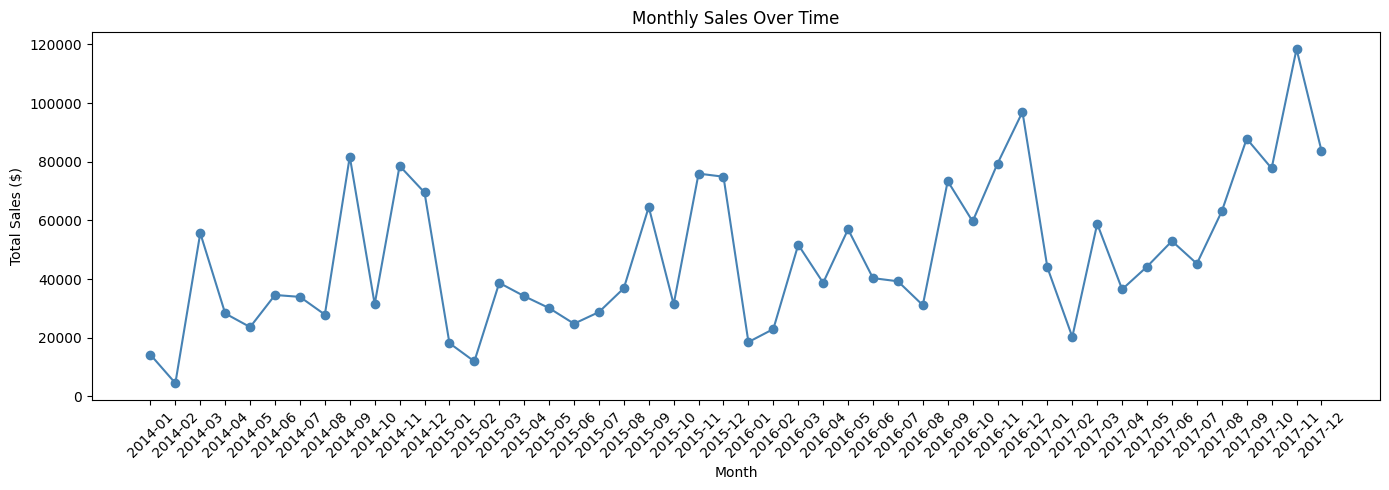

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['Sales'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Sales Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

## Stage 4 — Build the Forecasting Model
We use Holt-Winters Exponential Smoothing — one of the most reliable models
for business sales forecasting. It accounts for both trend and seasonality.
We train on all but the last 6 months, then forecast those 6 months to test accuracy.

In [6]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# Use Sales values as the time series
sales_series = monthly_sales['Sales'].values

# Split: last 6 months as test set
train = sales_series[:-6]
test = sales_series[-6:]

# Build and fit the model
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
fitted_model = model.fit()

# Forecast next 6 months
forecast = fitted_model.forecast(6)
print("Forecasted Sales:", forecast.round(2))

Forecasted Sales: [46343.61 47015.14 87969.64 47484.7  91912.5  87304.94]


## Stage 5 — Evaluate & Visualize Results
We measure accuracy using MAE (average dollar error) and RMSE (penalizes large
errors more). Then we plot actual vs forecasted sales — the most powerful visual
to show a client that the model works.

MAE: $12,931.85
RMSE: $17,768.85


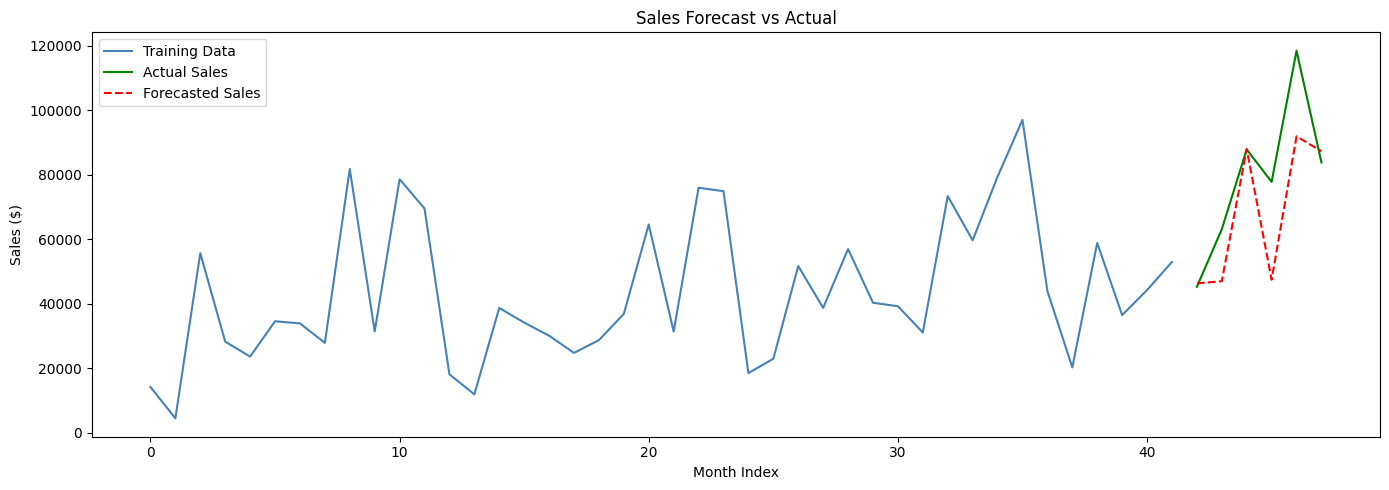

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate error metrics
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

# Plot actual vs forecasted
plt.figure(figsize=(14, 5))
plt.plot(range(len(train)), train, label='Training Data', color='steelblue')
plt.plot(range(len(train), len(train) + len(test)), test, label='Actual Sales', color='green')
plt.plot(range(len(train), len(train) + len(forecast)), forecast, label='Forecasted Sales', color='red', linestyle='--')
plt.title('Sales Forecast vs Actual')
plt.xlabel('Month Index')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Key Findings
- Sales show a clear upward trend over the observed period
- Strong seasonality detected — sales peak towards Q4 every year
- Model achieved an MAE of $12,931.85 and RMSE of $17,768.85 on the test set
- Businesses can use this forecast to plan inventory, staffing, and budgets in advance